# Spectra & summary statistics
Beyond scalar moments, the {class}`~phasegen.distributions.Coalescent` provides full *spectra* — the joint (multi-population) and two-locus site-frequency spectra — as well as a set of standard scalar summary statistics. All of these are exact and respect the full demography and coalescent model. See {doc}`coalescent` for how to configure the underlying model.

In [1]:
setwd("~/PycharmProjects/PhaseGen/")

In [2]:
library(phasegen)

pg <- suppressWarnings(load_phasegen())

In [3]:
# keep the rendered docs clean: silence informational logging and warnings
pg$logger$setLevel('ERROR')
options(warn = -1)

## Joint site-frequency spectrum
For multiple populations, {meth}`~phasegen.distributions.Coalescent.jsfs` gives the *joint* (multi-population) SFS: the expected branch length subtending each configuration of derived-allele counts *per population* (the deme of origin). For ``P`` populations it is a ``P``-dimensional {class}`~phasegen.spectrum.JointSFS` of shape ``(n_0 + 1, ..., n_{P-1} + 1)``, with higher moments available via {meth}`moment(k) <phasegen.distributions.JointSFSDistribution.moment>`, {meth}`var <phasegen.distributions.JointSFSDistribution.var>` and {meth}`cov <phasegen.distributions.JointSFSDistribution.cov>`. It is restricted to a single locus, and the state space grows quickly with the per-population sample sizes, so keep these small.

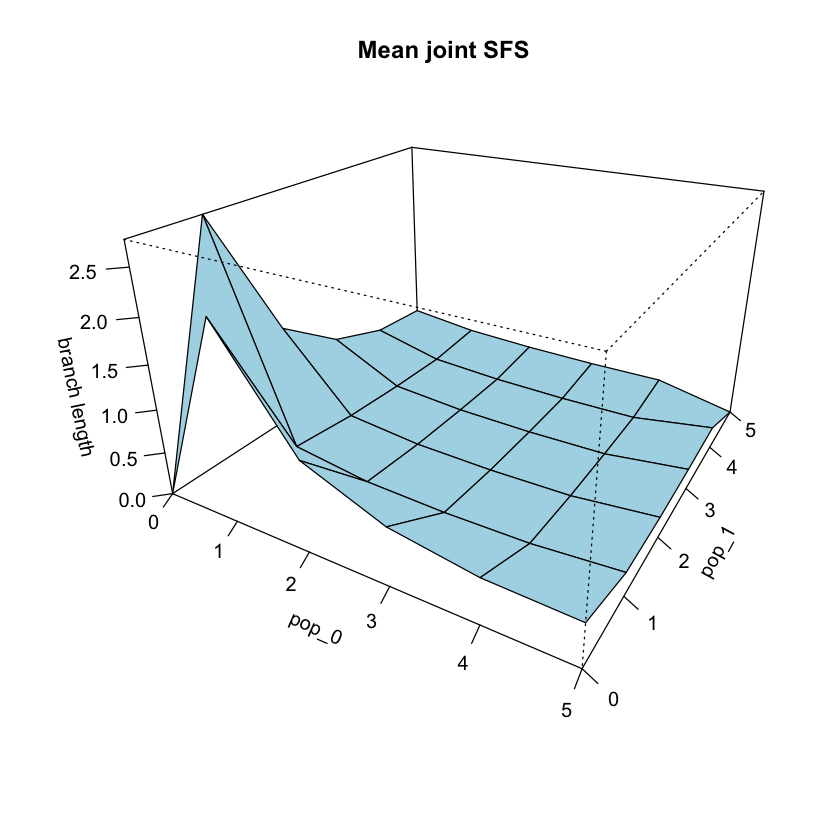

In [4]:
# a two-population demography with a population-size change in pop_0 and asymmetric migration
coal <- pg$Coalescent(
    n = list(pop_0 = 5, pop_1 = 5),
    demography = pg$Demography(
        pop_sizes = list(pop_0 = 1, pop_1 = 1.5),
        events = c(
            pg$PopSizeChange(pop = 'pop_0', time = 1, size = 0.3),
            pg$MigrationRateChange(source = 'pop_0', dest = 'pop_1', time = 0, rate = 0.5),
            pg$MigrationRateChange(source = 'pop_1', dest = 'pop_0', time = 0, rate = 0.2)
        )
    )
)

# mean joint SFS: expected branch length subtending each (pop_0, pop_1) allele-frequency configuration
persp(
    z = coal$jsfs$mean$data,
    x = 0:(nrow(coal$jsfs$mean$data) - 1), y = 0:(ncol(coal$jsfs$mean$data) - 1), theta = 30, phi = 25, expand = 0.6, col = 'lightblue',
    ticktype = 'detailed', xlab = 'pop_0', ylab = 'pop_1', zlab = 'branch length',
    main = 'Mean joint SFS'
)

## Two-locus SFS under recombination
For two loci separated by recombination rate ``r``, {meth}`~phasegen.distributions.Coalescent.sfs2` gives the *two-locus* SFS: entry ``(i, j)`` is the expected product of the branch length subtending ``i`` samples at locus 0 and ``j`` samples at locus 1, interpolating between the fully linked (``r = 0``) and independent (``r → ∞``) regimes. A single population is supported.

The single- and two-locus spectra guard each other: {meth}`~phasegen.distributions.Coalescent.sfs2` requires exactly two loci, while the single-locus {meth}`~phasegen.distributions.Coalescent.sfs` requires one (its marginal mean is recombination-invariant, so to obtain it for one locus simply drop the other).

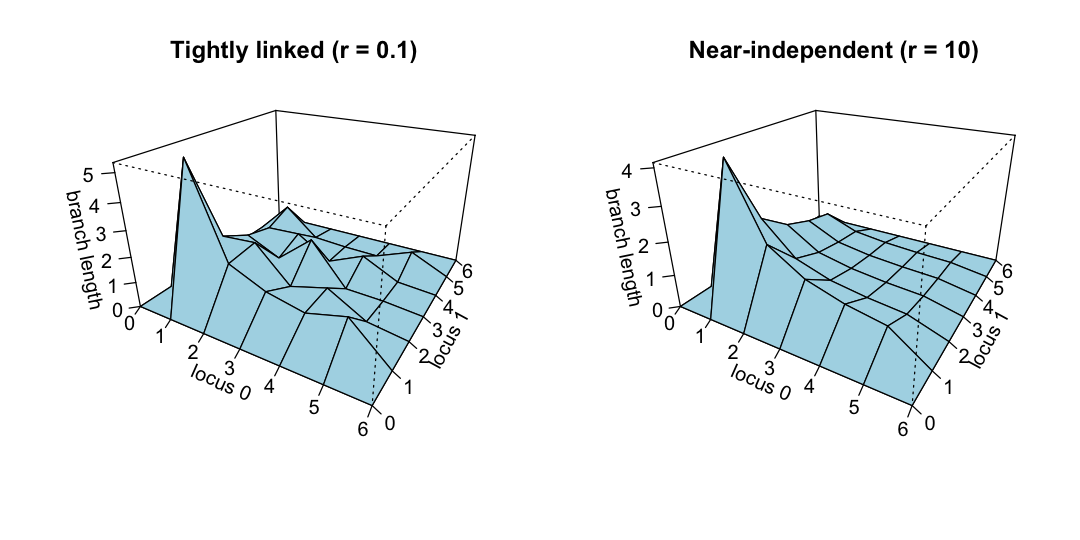

In [5]:
# the two-locus SFS interpolates between tightly linked and independent loci as r grows
options(repr.plot.width = 9, repr.plot.height = 4.5)
par(mfrow = c(1, 2))

# r = 0.1: tightly linked -> strong cross-locus structure (close to the within-tree SFS covariance)
low <- pg$Coalescent(n = 6, loci = 2, recombination_rate = 0.1)
persp(z = low$sfs2$mean$data,
      x = 0:(nrow(low$sfs2$mean$data) - 1), y = 0:(ncol(low$sfs2$mean$data) - 1), theta = 30, phi = 25, expand = 0.6, col = 'lightblue',
      ticktype = 'detailed', xlab = 'locus 0', ylab = 'locus 1', zlab = 'branch length',
      main = 'Tightly linked (r = 0.1)')

# r = 10: nearly independent -> approaches the outer product of the marginal SFS
high <- pg$Coalescent(n = 6, loci = 2, recombination_rate = 10.0)
persp(z = high$sfs2$mean$data,
      x = 0:(nrow(high$sfs2$mean$data) - 1), y = 0:(ncol(high$sfs2$mean$data) - 1), theta = 30, phi = 25, expand = 0.6, col = 'lightblue',
      ticktype = 'detailed', xlab = 'locus 0', ylab = 'locus 1', zlab = 'branch length',
      main = 'Near-independent (r = 10)')

## Summary statistics
Beyond full spectra, several standard scalar summaries are available directly from the {class}`~phasegen.distributions.Coalescent`, each respecting the full demography and coalescent model:

- **Population structure** — Hudson's {meth}`~phasegen.distributions.Coalescent.fst` and Patterson's f-statistics ({meth}`~phasegen.distributions.Coalescent.f2`, {meth}`~phasegen.distributions.Coalescent.f3`, {meth}`~phasegen.distributions.Coalescent.f4`), all derived from inter-population pairwise coalescence times.
- **Linkage** — the correlation of coalescence times between two loci ({meth}`tree_height.loci.get_corr <phasegen.distributions.MarginalLocusDistributions.get_corr>`), which decays towards zero as the recombination rate grows.
- **SFS skew** — Tajima's {meth}`~phasegen.distributions.UnfoldedSFSDistribution.tajimas_d`, together with the underlying {meth}`~phasegen.distributions.UnfoldedSFSDistribution.theta_pi` and {meth}`~phasegen.distributions.UnfoldedSFSDistribution.theta_w` estimators.

We illustrate them on a relatively complex scenario: a structured three-population demography with asymmetric population sizes and migration.

In [6]:
# a structured three-population demography with asymmetric sizes and migration
struct <- pg$Coalescent(
    n = list(pop_0 = 2, pop_1 = 2, pop_2 = 2),
    demography = pg$Demography(
        pop_sizes = list(pop_0 = 1.0, pop_1 = 1.0, pop_2 = 1.5),
        migration_rates = reticulate::py_dict(
            keys = list(
                reticulate::tuple('pop_0', 'pop_1'), reticulate::tuple('pop_1', 'pop_0'),
                reticulate::tuple('pop_1', 'pop_2'), reticulate::tuple('pop_2', 'pop_1'),
                reticulate::tuple('pop_0', 'pop_2'), reticulate::tuple('pop_2', 'pop_0')
            ),
            values = list(0.5, 0.5, 0.2, 0.2, 0.2, 0.2)
        )
    )
)

In [7]:
# population structure: Hudson's F_ST and Patterson's f-statistics
cat(sprintf("F_ST                    = %.3f\n", struct$fst))
cat(sprintf("f2(pop_0, pop_2)        = %.3f\n", struct$f2('pop_0', 'pop_2')))
cat(sprintf("f3(pop_1; pop_0, pop_2) = %.3f\n", struct$f3('pop_1', 'pop_0', 'pop_2')))

F_ST                    = 0.348


f2(pop_0, pop_2)        = 4.097


f3(pop_1; pop_0, pop_2) = 1.361


In [8]:
# linkage: correlation of coalescence times between two loci, decaying with recombination
for (r in c(0.1, 1.0, 10.0)) {
    corr <- pg$Coalescent(n = 2L, loci = 2L, recombination_rate = r)$tree_height$loci$get_corr(0L, 1L)
    cat(sprintf("corr(T_A, T_B) at r=%-4s = %.3f\n", format(r, nsmall = 1), corr))
}

corr(T_A, T_B) at r=0.1  = 0.882
corr(T_A, T_B) at r=1.0  = 0.417
corr(T_A, T_B) at r=10.0 = 0.056


In [9]:
# SFS skew: Tajima's D under recent population growth (excess of low-frequency variants -> D < 0)
growth <- pg$Coalescent(
    n = 10L,
    demography = pg$Demography(
        pop_sizes = list(pop_0 = reticulate::py_dict(keys = list(0, 0.5), values = list(1.0, 0.1)))
    )
)
cat(sprintf("Tajima's D (growth) = %.3f\n", growth$sfs$tajimas_d))

Tajima's D (growth) = -1.263
